In [2]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import math
import os
import pandas as pd

### Problem Set 6 Guidelines

**ASSIGNED:**  February 13, 2026

**DUE:**  Friday, February 20, 2026 at 9:00 pm submitted on Canvas.  Problem sets more than 24 hr late will not be accepted.

1. Each solution must be your own work.
2. All problems that involve python must be completed in Jupyter Notebooks.  Some problems may not require python and may be better completed with pen and paper.  
3. Highlight your final answer when providing numerical results.  Provide plots, graphs, and tables of your results when appropriate.
4. **Submission Instructions:**  This quarter we will use Canvas to collect your submissions and grade them.  We ask that you submit **both** your Jupyter Notebook file and a single PDF with your compiled solutions.  Please follow the instructions below to obtain a PDF file from a Jupyter Notebook:
    - Make sure all your code runs without error, and all figures (if any) show up where intended.  We will not be running your code, therefore it is essential that your solutions output and highlight your results.  Please be mindful of your line length so that it fits into the PDF layout and your results are clearly shown.
    - Select File->Download as->HTML (.html).  This will download an HTML version your_homework.html of your notebook to your computer, typically in your Download folder.
    - Open your_homework.html in your web browser (just double-click on it).  Use the File->Print command of your browser to produce a PDF file.  (Do not produce the PDF in other ways, such as “Export to PDF” or other.  Alternative methods will usually produce poor page margins, format headers differently, fail to incorporate figures, and so forth.)
    - Submit your PDF file your_homework.pdf to Canvas.  Do not submit your HTML file.  
5. Note that you can wrap lines of python code **using the “\” operator** to ensure that all your code is visible within the width of the PDF page.  Please do so wherever appropriate.

### Problem 1 - 2D Contour Maps

Focused Ion Beams (FIB) are common tools for fabricating nanostructured photonic devices. A very tired graduate student forgets to calibrate the FIB before patterning her device and discovers that the ions have been implanted into the substrate, thus creating an undesired residual electric field. She can measure the field, and uses this data to develop a model:

$$
\vec{E}(x,y) = E_x \,\vec{x} + E_y \,\vec{y}
= (x^3 - 4x^2 + 2x^2y)\,\vec{x}
+ (2y^3 + 2y^2 + 1.5y)\,\vec{y}
$$


in units of $nV/{μ}m$. This (now extremely tired) graduate student is interested in calculating the distribution of ions in her device, so that she can correctly calibrate the FIB in the future.

Generate a contour plot of the electric field magnitude and electric vector field (with arrows) side by side over the domain [(-5, -5), (5, 5)]. Please include a color bar, and provide labels and correct units for all three axes (two spatial axes and one on the color bar for field strength). You are encouraged to play around with different color schemes - the color gradients are quite cool in 2D!

You may find the following functions helpful: `meshgrid()` of the `numpy` library, plus `quiver()` and `contourf()` of the `matplotlib.pyplot` library.  The documentation for these three functions can be accessed at:

* Creating a meshgrid: https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html

* `quiver()` for plotting vectors:
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html

* `contourf()` for creating contour maps:
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html

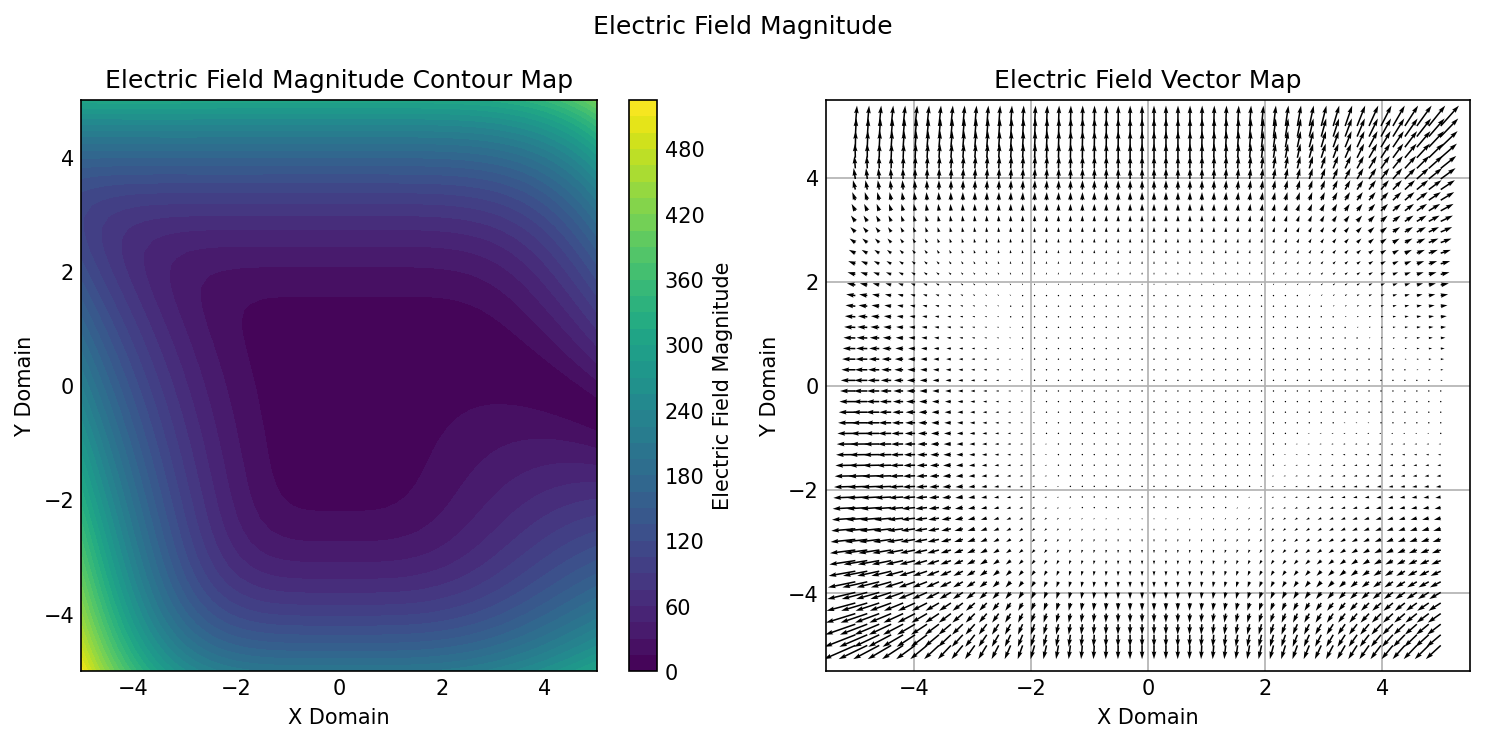

In [961]:
from numpy import meshgrid
from matplotlib.pyplot import quiver
from matplotlib.pyplot import contourf

def electric_field_mag(x,y):
    return np.sqrt((x**3 - 4*(x**2) + 2*(x**2)*y)**2 + (2*(y**3)+2*(y**2)+1.5*y)**2)


def electric_field(x,y):
    EX = (x**3) - (4*(x**2)) + (2*(x**2)*y)
    EY = (2*(y**3)) + (2*(y**2)) + (1.5*y)
    return EX, EY
x_range = np.linspace(-5,5,50)
y_range = np.linspace(-5,5,50)
e_fieldx,e_fieldy = meshgrid(x_range,y_range)
test = electric_field_mag(e_fieldx,e_fieldy)



U, V = np.meshgrid(x_range, y_range)

e_field_vecx, e_field_vecy = electric_field(U,V)


plt.figure(figsize=(10,5),dpi=150)

plt.subplot(121)
e_field = plt.contourf(e_fieldx, e_fieldy,test,levels=50,cmap="viridis")
bar = plt.colorbar(e_field)
plt.title("Electric Field Magnitude Contour Map")


bar.set_label("Electric Field Magnitude")

plt.xlabel("X Domain")
plt.ylabel("Y Domain")

plt.subplot(122)


q = plt.quiver(U, V, e_field_vecx, e_field_vecy)
plt.xlabel("X Domain")
plt.ylabel("Y Domain")
plt.suptitle("Electric Field Magnitude")
plt.title("Electric Field Vector Map")
plt.tight_layout()
plt.show()

### Problem 2 - Percussive Maintenance

You, a MENG major, have decided that it is time to develop some new hobbies. After a period of introspection, you decided to take up music. After a secondary period of extrospection, you are informed that you are most likely tone deaf. No matter&mdash;your academic vocation has trained you to roll with the punches, and you pivot to learning the drums.

During a late night bongo session, you accidentally knock an energy drink onto your drumheads. After smacking the bongos in exasperation, you notice that the liquid vibrates in a symmetric way. Inspiration strikes! You will elucidate the vibrational modes by solving a boundary value problem (BVP) of the 2D wave equation with the finite difference approach.

For the purposes of this analysis, let's assume you play square bongos with side length of $L$, where $c$ is the wave speed. You are only interested in recreating the vibrational patterns, so let's take both $c$ and $L$ to be unitless for simplicity.

$$ u_{tt} = c^2\nabla^2 u \quad \text{with} \quad x \in (0,L) \text{ and } y \in (0, L)$$

We will assume that the solution $u(x,y,t)$ is separable into a spatial part $\phi(x,y)$ and temporal part $T(t)$.  Recall that the notation $u_{tt}$ means the second derivative with respect to time (*i.e.*, $u_{tt}=d^2u/dt^2$).

(a) What boundary conditions should this system have? Justify your choice.

These are waves, and waves have starting and endpoint "nodes." Because of this, the position must equal zero at the boundaries of the waves, so  $\phi(0,y)$ = $\phi(L,y)$ = 0, and $\phi(x,0)$ = $\phi(0,L)$ = 0

(b) Using separation of variables, solve for the spatial eigenproblem of the 2D wave equation (*i.e.*, derive that $-\nabla^2 \phi= \lambda \phi$).

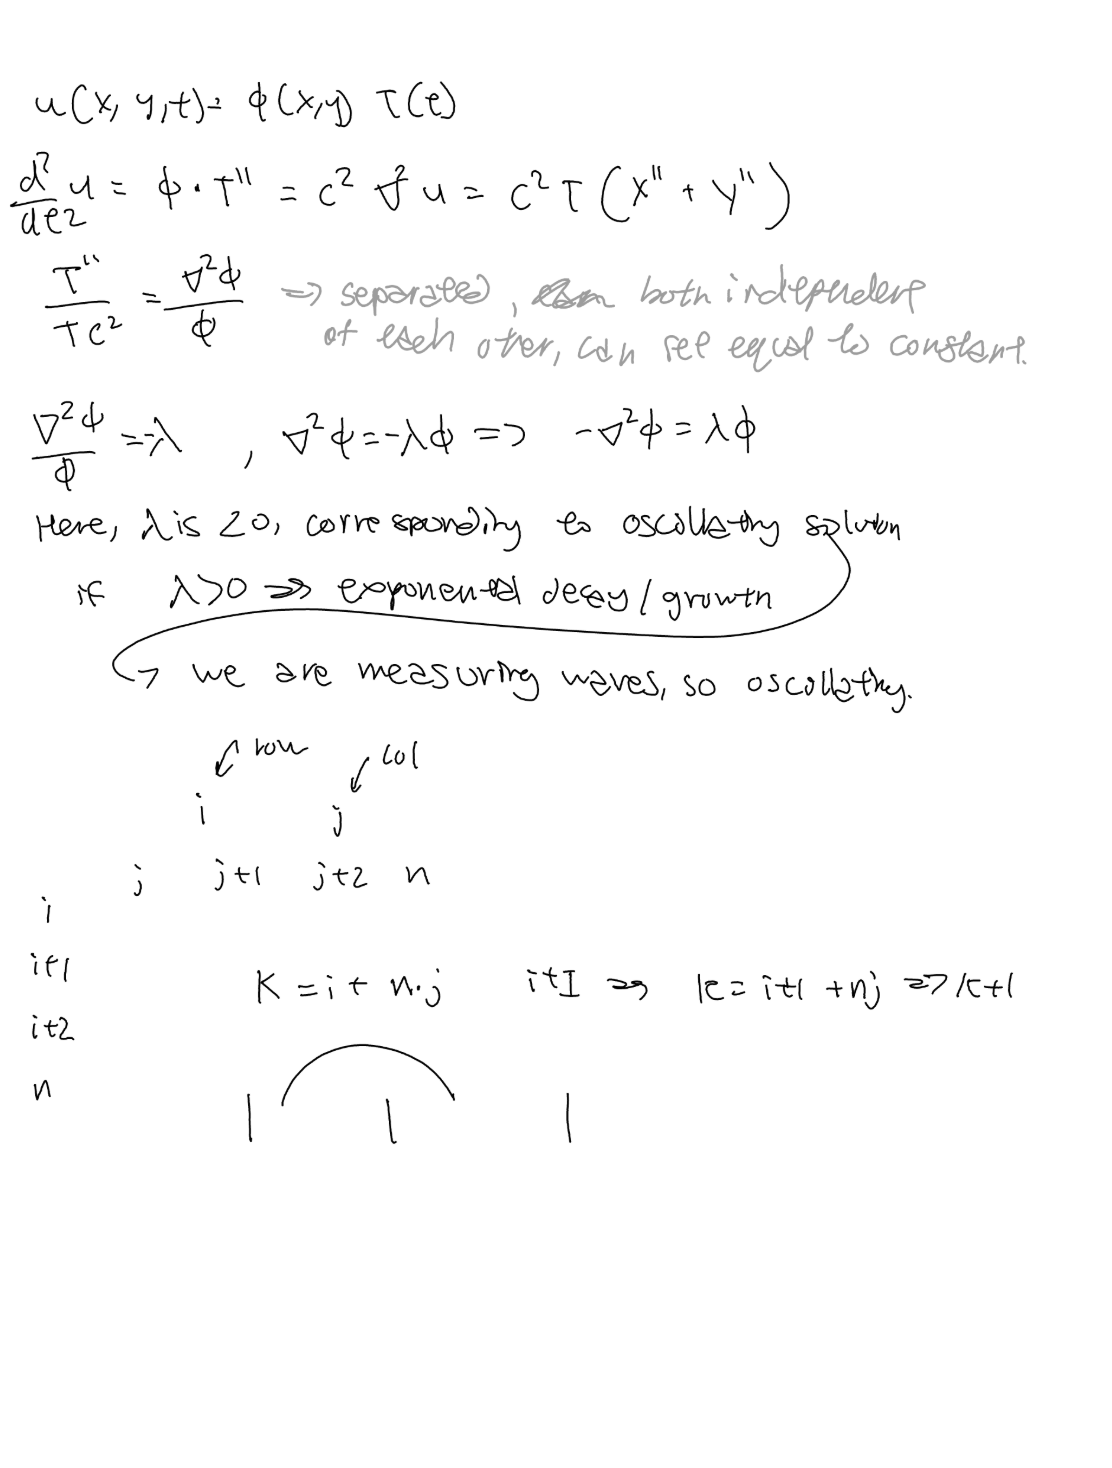

(c) Given the finite-difference approximation for the 2D Laplacian ($\nabla^2$), write a function that evaluates the above eigenproblem with the following arguments: `n` as the number of internal points in each spatial direction (*i.e.*, the matrix eigensystem you are solving will be $n^2 \times n^2$),`m` as the number of vibrational modes to evaluate, and `L` as the side length of your square drum and `L` as the side length of your square drum. Your function should return the eigenvalues and eigenvectors of the first `m` modes.

You will find the function `np.linalg.eigh` useful in solving your matrix system.  In addition, you should use the 5-point finite-difference approximation for $-\nabla^2$:
$$-\nabla^2\phi=\frac{4\phi_{i,j}-\phi_{i+1,j}-\phi_{i-1,j}-\phi_{i,j+1}-\phi_{i,j-1}}{h^2}$$

with $i, j$ indexing corresponding to positions on an $(x,y)$ grid and $h$ being the grid spacing (assuming equal grid spacing in both the x and y directions).

*This finite-difference approximation should look familiar. Remember the 2nd order ($O(h^2)$) central finite-difference approximation (CFD) for the second derivative.*
$$f''(x_i) = \frac{f(x_{i+1})-2f(x_i)+f(x_{i-1})}{h^2}$$

*The finite-difference of the Laplacian is effectively two of these 1D CFDs layered on top of one another.*

HINT:  Build your $\phi$ vector like this for the $n$ interior points.
$$
\phi
=
\begin{bmatrix}
\phi_{1,1}\\
\phi_{2,1}\\
\vdots\\
\phi_{n,1}\\[6pt]
\phi_{1,2}\\
\phi_{2,2}\\
\vdots\\
\phi_{n,2}\\[6pt]
\vdots\\[6pt]
\phi_{1,n}\\
\phi_{2,n}\\
\vdots\\
\phi_{n,n}
\end{bmatrix}
$$

In [962]:
from numpy.linalg import eigh

#we are trying to find the lambda values. 
def matrix_maker_phi(n,m,L):
    matrix = np.zeros((n**2,n**2))

#n is internal points

#step for n+1 points, because the number of gaps is always one minus the number of points
# , and n is interior points, so n+2 is number of total points, n-1 is number of gaps
    h=L/(n+1)
    for i in range(0,n):#column
        for j in range(0,n):#row
            index = j + i*n
#phi is a 1D matrix. this means that our matrix also needs to be "1D". in this case, the
# 1 dimension is index. 
#phi goes by filling out the row in each column, and them moving to the next column, thus
#  our index should also do that.
#index = 0,1,2 => j = 1,2,3 (filling out the row), and i = 0 (first column)
#index = 3,4,5 => j = 1,2,3 (filling out the row), and i = 1(second column)
            matrix[index,index]=4 #from the equation

#we also need to look at our boundary conditions. at the edges of our matrix/drum, the 
# phi function = 0. 
#thus, at the bottom and top rows, left and right side, we need to create exceptions

#i==0 means we're at the 0th column, so left side boundary should equal 0
#for the columns, to go "left" or "right" column, we move by n because of our equation
#  before:
    #where index = j+i*n, to shift columns we iterate by the n value
            if i==0:
                #matrix[index,index-n]=0
                pass
            else: 
                #index-1 is the index to the left
                matrix[index,index-n]=-1

#i = n-1 means we're at the n-1st column, so right side boundary
            if i==n-1:
                #matrix[index,index+n]=0
                pass
            else: 
                #index+n is index to the right
                matrix[index,index+n]=-1

#now we need to do the bottom and top boundaries. 
#because we're going up by a step, we start at the bottom

#j==0 is the bottom
            if j==0:
                #matrix[index,index-1] = 0
                pass
            else:
                matrix[index,index-1]=-1

#j==n-1 is the top
            if j==n-1:
                #matrix[index,index-1]=0
                pass
            else:
                matrix[index,index+1]=-1

    matrix = matrix/(h**2)
    return matrix

def eigen_solver(n,m,L):
    A = matrix_maker_phi(n,m,L)
    eigenvalues,eigenvectors = eigh(A)

    return eigenvalues[:m], eigenvectors[:,:m]


(d) Write a plotting function that takes `e_vals` as the eigenvalues, `e_vecs` as the eigenvectors, and `L` as the side length of the square drumhead. The function should plot the time-independent height of the drumhead $\phi(x,y)$ on an $n \times n$ grid. Make sure to normalize $\phi(x,y)$ for each mode in order to make later comparison easier.

You will find the functions `.reshape((n,n))` and `plt.contourf` useful.

Note: If you were to model the time evolution of the drum, the shape of the vibrational mode would remain the same, but the amplitude would change.

In [963]:
def plot_func(e_vals,e_vecs,L):
    n=int(np.sqrt(len(e_vecs)))
    h=L/(n+1)
    X= np.linspace(h,L,n)
    Y= np.linspace(h,L,n)
    U,V = np.meshgrid(X,Y)
    #grid = e_vecs.reshape(n,n)
    plt.figure(figsize=(10,10))
    num=1
    for i in range(0,len(e_vals)):

# In your plot_func:
# This effectively sets your 'B' constant to 1.0
        plt.subplot(int((len(e_vals))/2),int((len(e_vals))/2),i+1)

      #  plt.subplot(len(e_vals)+1,len(e_vals)+1,i+1)
#order is the order that the reshape reshapes/reads. in our case, we have our matrix 
# filling up the rows, and then moving the columns, so we do order F
#where "first index changest fastest" (row) and "second index changest slowest" (col)
        #since each mode / m value for our eigenvector is a different column, we want 
        # to plot m vectors (m columns)
        wave = e_vecs[:,i].reshape((n,n),order='F')
        nornalized_wave = (wave / (np.max(np.abs(wave)))).reshape((n,n),order='F')

#.reshape((n,n),order='F')
        plt.title(f"Lambda Value: {e_vals[i]:.2f}, mode = {i+1}")
        test = plt.contourf(U,V,nornalized_wave,levels=100,cmap="viridis")

        if num % 2 != 0:
            plt.ylabel("Bongo Square Width Dimension")
        else:
            bar=plt.colorbar(test)
            bar.set_label("Bongo Drumhead Height")
             
        if num == len(e_vals)-1 or num==len(e_vals):
             plt.xlabel("Bongo Square Length Dimension")

        
        plt.tight_layout()
        num+=1
    plt.suptitle("Bongo Drum Height vs X,Y Oscillations ")
    plt.tight_layout()
    plt.show()

(e) Using $n=20$ internal points, plot the first 4 vibrational modes. Take $L=1$ for convenience.

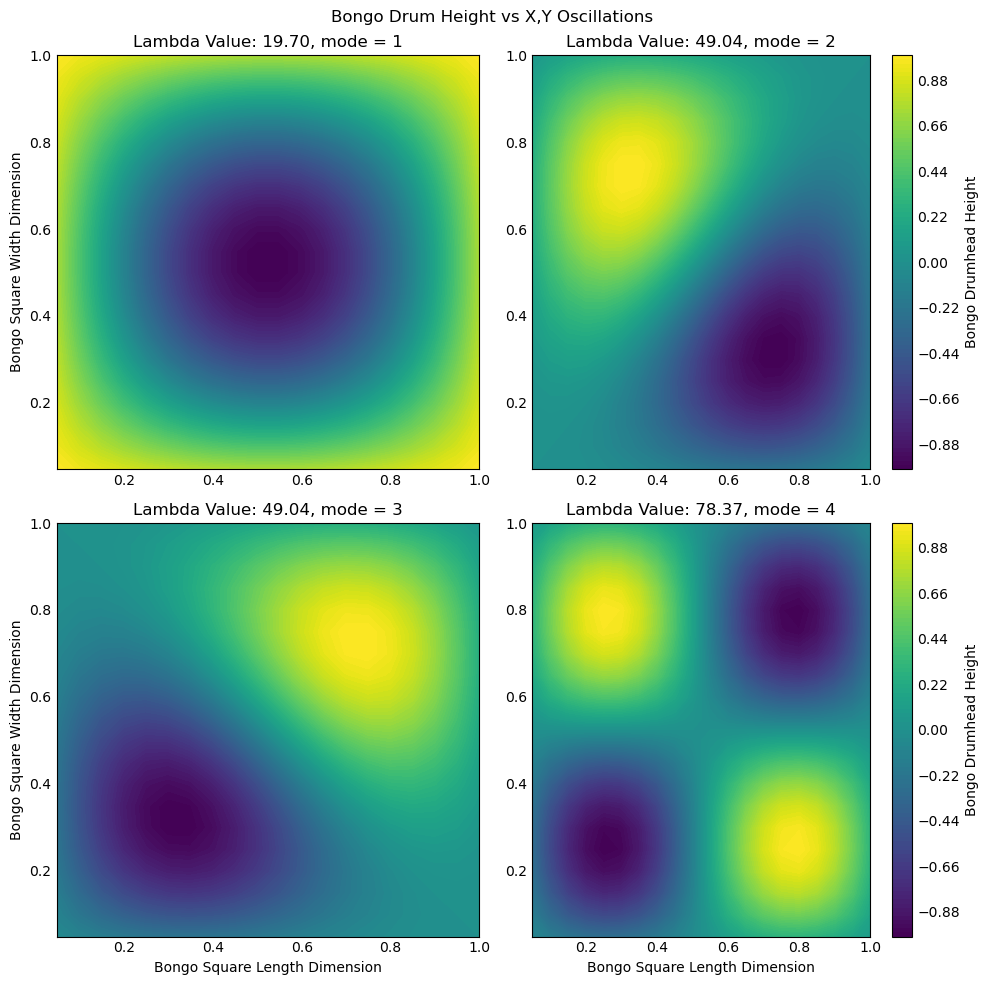

In [820]:
eigenvalues,eigenvector = eigen_solver(20,4,1)

#print(eigenvector.shape)

test = plot_func(eigenvalues,eigenvector,1)
#test.title("test")
# plt.ylabel("Bongo Square Width Dimension")
# bar=plt.colorbar(test)
# bar.set_label("Bongo Drumhead Height")

(f) To verify you have plotted the correct vibrational modes, solve the spatial eigenproblem ($-\nabla^2 \phi= \lambda \phi$) analytically and visualize the results.

When solving analytically, you will notice that your solution for $\phi$ is dependent on a pair of integer constants. Plot the first 4 analytical modes with the following pairs of constants:
$$(c_x,c_y) = [(1,1),(1,2),(2,1),(2,2)]$$

Again, take $L=1$. Make sure to normalize your analytically computed $\phi(x,y)$ for each mode. You may find `np.meshgrid` helpful.

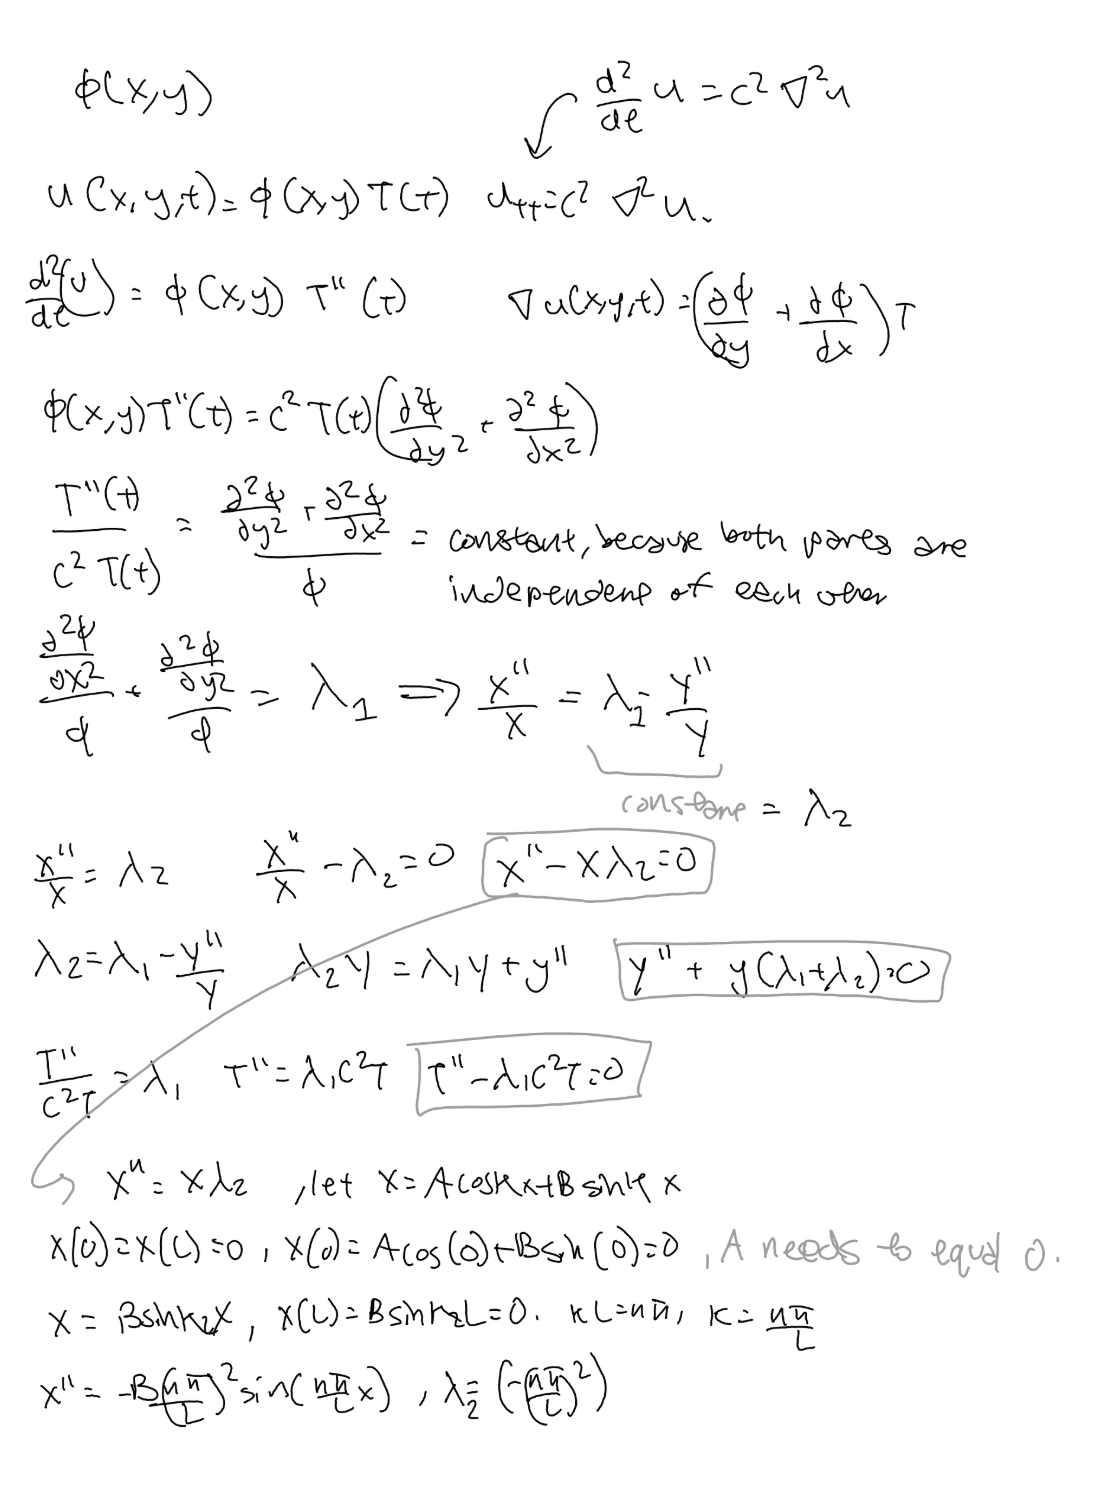
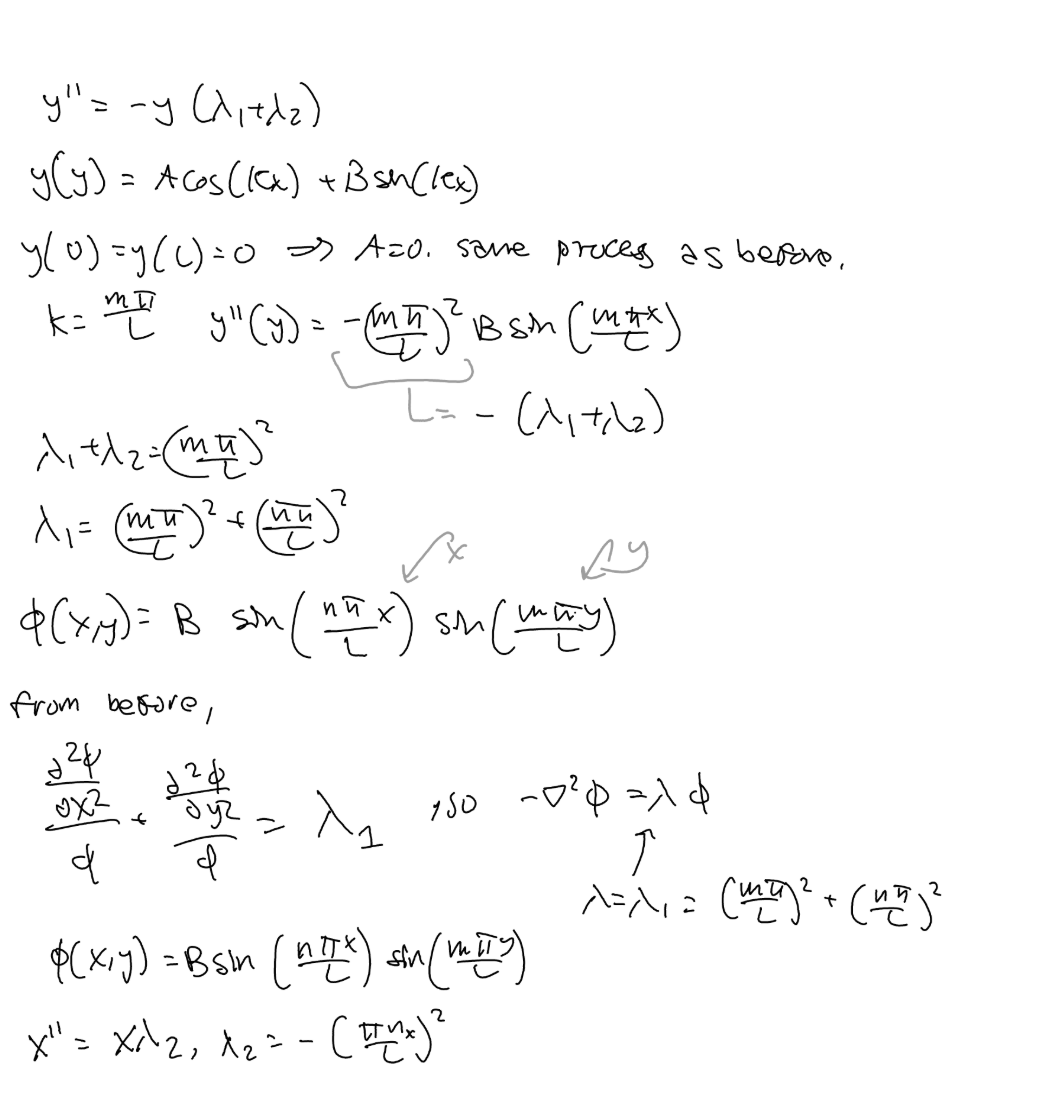

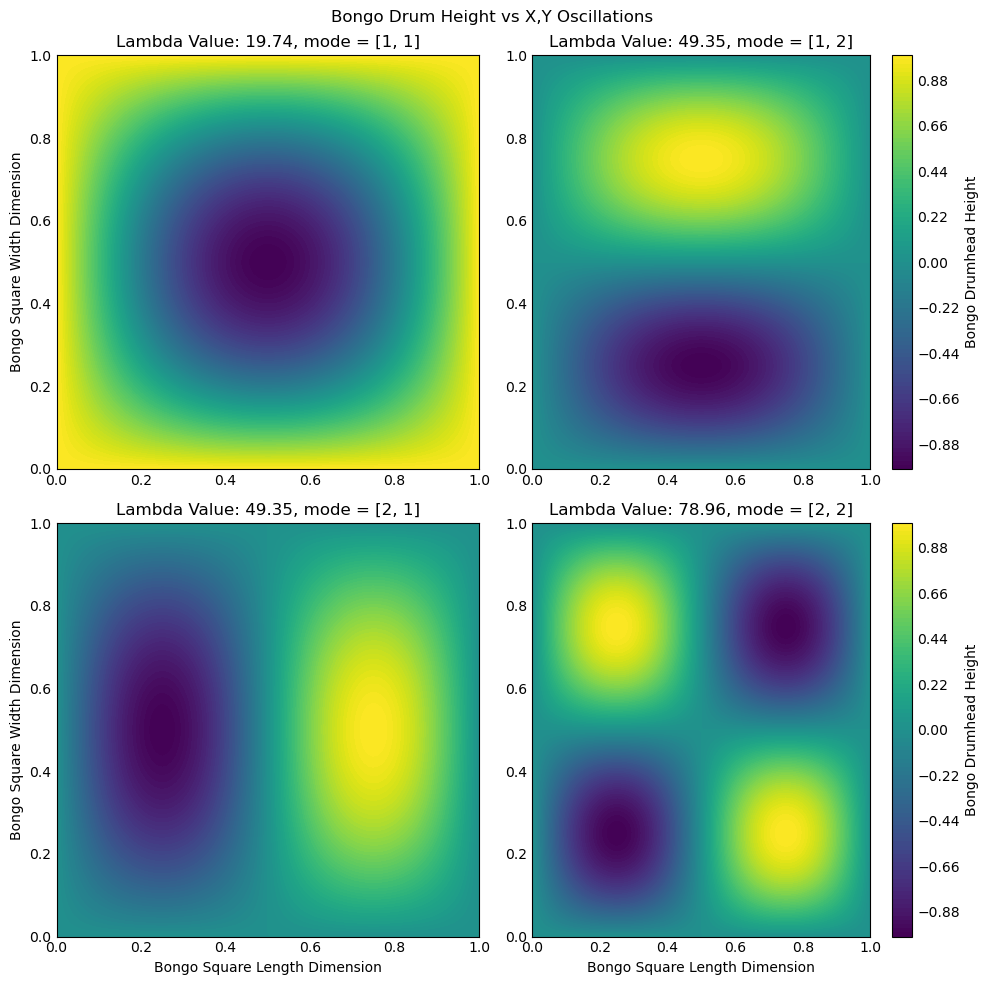

In [830]:
def analytical_phi(x,y,constant,L):
    cx,cy=constant[0],constant[1]
    #in this case, our integer constants are the n and m values
    return -np.sin((cx*np.pi*x) / L)*np.sin((cy*np.pi*y) / L)

def eigen_vals_lambda(constant,L):
        cx,cy=constant[0],constant[1]
        return (((cx*np.pi)/L)**2)+(((cy*np.pi)/L)**2)

constants = [[1,1],[1,2],[2,1],[2,2]]

L=1

def values_vectors(constant,L,n):
    X=np.linspace(0,L,n)
    Y=np.linspace(0,L,n)
    U,V = np.meshgrid(X,Y)
    phi = analytical_phi(U,V,constant,L)
    eigen_values=eigen_vals_lambda(constant,L)
    nornalized_wave = (phi / (np.max(np.abs(phi))))
    return nornalized_wave,eigen_values,U,V

def plot_func2(constants,L,n):
    plt.figure(figsize=(10,10))
    num=1
    for i in constants:
        phi,eigenvals,U,V = values_vectors(i,L,n)

        plt.subplot(int((len(constants))/2),int((len(constants))/2),num)
        
        plt.title(f"Lambda Value: {eigenvals:.2f}, mode = {i}")
       # plt.title(f"Lambda Value: {eigenvals:.2f}, mode = {i+1}")
        test=plt.contourf(U,V,phi,levels=n,cmap = "viridis")
        if num % 2 != 0:
            plt.ylabel("Bongo Square Width Dimension")
        else:
            bar=plt.colorbar(test)
            bar.set_label("Bongo Drumhead Height")
             
             
        if num == len(constants)-1 or num==len(constants):
             plt.xlabel("Bongo Square Length Dimension")
        
        plt.tight_layout()
        num+=1
    plt.suptitle("Bongo Drum Height vs X,Y Oscillations ")
    plt.tight_layout()
    plt.show()

testing = plot_func2(constants,L,100)


(g) What do you observe?

HINT: Consider printing the eigenvalues.

HINT: Eigenvectors with degenerate eigenvalues can be linearly combined to also return a valid eigensolution.

We observe the osciliatory wave-function motion of the height of the bongo drum each time it is hit. This is dependent on mode, which dictates how many nodes there are in the wave. this is represented by the number of "splitting" in the contour graph. For example, the top left graph is the fundamental wave motion, and the top right has one horizontal split (corresponding to the 2 in the y value of the mode.)

We can also observe that two of the solutions having the same eigenvalues, which means the solutions are degenerate, but still valid eigensolutions. This means they have the same energy and height values. In general, lambda values are also increasing. Additionally, because graphs 2 and 3 are degnerate, we can linearly combine them to also produce a valid eigensolution

(h) Triple-checking never hurts, so also use `sc.integrate.solve_bvp` to solve for the  same 4 vibrational modes, using their respective $(c_x,c_y)$ pairs. `sc.integrate.solve_bvp` only works in one dimension, so you will have to be clever to construct your solution for $\phi(x,y)$. Again, make sure to normalize.

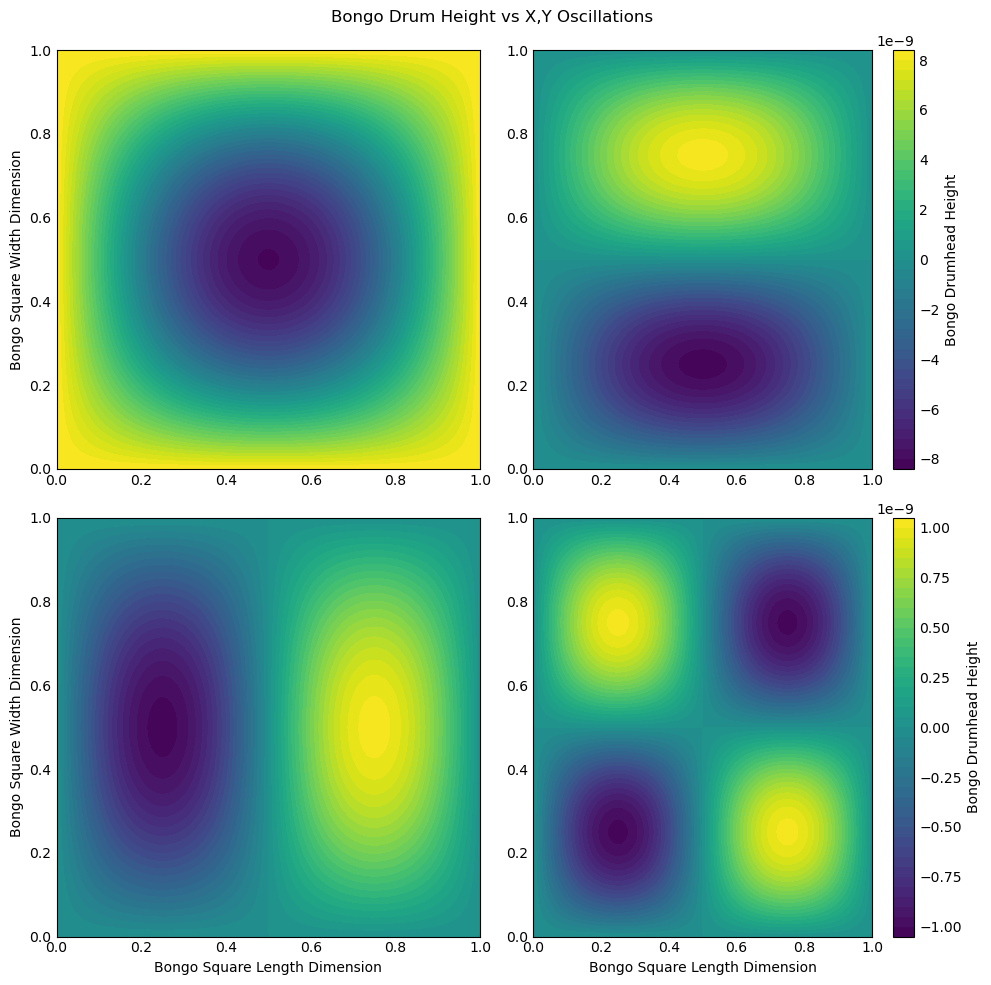

In [832]:
from scipy.integrate import solve_bvp

#x ODE

def x_ODE(x,y,cx):
    return np.vstack( (y[1],-(((((np.pi*cx)/L)))**2)*y[0]))

def y_ODE(x,y,cy):
    return np.vstack( (y[1],(-((((np.pi*cy)/L)))**2)*y[0]))

def bcY(ya,yb):
    return np.array([ ya[0],yb[0]])

def bcX(xa,xb):
    return np.array([ xa[0],xb[0]])

y_range = np.linspace(0,L,100)
y=np.zeros((2,y_range.size))
y[0,1]=1
y[0,3]=-1


x_range = np.linspace(0,L,100)
x=np.zeros((2,y_range.size))
x[0,1]=1
x[0,3]=-1


constants = [[1,1],[1,2],[2,1],[2,2]]
plt.figure(figsize=(10,10))
num=1
for cxcy in constants:
    cy = cxcy[1]
    cx=cxcy[0]
    plt.subplot(int((len(constants))/2),int((len(constants))/2),num)

    y_height=solve_bvp(lambda x,y: y_ODE(x,y,cy),bcY,y_range,y)
    x_height=solve_bvp(lambda x,y: x_ODE(x,y,cx),bcX,x_range,x)
    x_plot=x_height.sol(x_range)[0]
    y_plot=y_height.sol(y_range)[0]
    x_test,y_test=meshgrid(x_plot,y_plot)
    testing = -x_test*y_test
    grad = plt.contourf(x_range,y_range,testing,levels=45,cmap = "viridis")

    if num % 2 != 0:
        plt.ylabel("Bongo Square Width Dimension")
    else:
        bar=plt.colorbar(grad)
        bar.set_label("Bongo Drumhead Height")
            
            
    if num == len(constants)-1 or num==len(constants):
            plt.xlabel("Bongo Square Length Dimension")
    plt.tight_layout()
    plt.suptitle("Bongo Drum Height vs X,Y Oscillations ")


    num+=1


### Problem 3 - The Computational Complexity of Linear Algebra Methods in python

<font color='red'>** **This problem will be covered in Discussion 6 on February 17**</font>

When applying linear algebra methods, we are often working with 1000 x 1000 or greater sized matrices. Understanding the computational complexity of such methods is then paramount in building code that can be applied to solve these systems in reasonable, well-defined amounts of time.

** Note that some of these tests may take a long time (several tens of minutes) to run. To receive full credit, you must complete each N, so make sure to reserve time to run your code.

(a) Write a function that takes an integer N as input and returns (i) a N x N matrix consisting of random (non-integer) values from -10 to 10 and (ii) a vector of size N x 1 again of random (non-integer) values from -10 to 10.  The random numbers should be selected from a uniform distribution for which the library function `random.uniform` may be useful.

In [879]:
from numpy.random import uniform
def matrix_maker(N):
    test = uniform(-10,10,(N,N))
    test2 = uniform(-10,10,(N))
    return test,test2

test,test2=matrix_maker(4)
print(test)
print(test2)

[[ 7.70274592 -6.24127589 -5.87609767 -2.12341984]
 [ 0.50483481  2.40685959  5.58710891  8.28907166]
 [ 9.05822085 -7.74505692  8.91547382 -2.85107381]
 [-2.4828357  -5.75306386 -3.01438293 -6.9846205 ]]
[ 5.36497993  0.86698811  7.67173554 -5.18606455]


(b) Write a function for the Gaussian elimination method that includes scaling and partial pivoting operations to better condition your matrix. You may find that the pseudocode in Figures 9.4 – 9.6 of Chapra and Canale provides a good starting point for this task.  Do not provide a function that implements only the naïve Gaussian elimination method!

In [880]:
#NON NAIIVE MEANS WE'RE USING PARTIAL PIVOTING
#figure 9.6

#n is our matrix dimensions
#a is our coefficients
#b is our solution 
#n is
#x is


def back_substitution(A,b):
    n=len(b)
    x=np.zeros(n)

    for i in range(n-1,-1,-1):
        sum_ax = 0
        for j in range(i+1,n):
            sum_ax += A[i,j] * x[j]

        x[i] = ((b[i] - sum_ax) / A[i,i]).item()
    return x 

def gauss2(A,b,tol=1.0e-9):
    A = A.astype(float,copy=True)
    b = b.astype(float,copy=True)

    n=len(b)
    s=np.zeros(n)
    x = np.zeros(n)
    er = 0 
    for i in range(n):
        s[i]=max(abs(A[i,:]))

    for k in range(n-1):
        pivot(A,b,s,n,k)

        if abs(A[k,k] / s[k]) < tol:
            er = -1
            break
        for i in range(k+1,n):
            factor = A[i,k] / A[k,k]
            for j in range(k,n):
                A[i,j]-= factor * A[k,j]
            b[i] -= factor * b[k]
    if abs(A[n-1,n-1] / s[n-1]) < tol:
        er = -1
    if er!= -1:
        x= back_substitution(A,b)

    return x,er


def pivot(A,b,s,n,k):
    p = k #p is our current column
    big = abs(A[k,k] / s[k])
    #this is normalizing / scaling our current row
    for i in range(k+1,n):
        temp = abs(A[i,k] / s[i])
        #this is looking at the row underneath
        if temp>big:
            big = temp
            p=i
            #if our row under is bigger than our current row, make it the new biggest row
            #update our row index
            #keep repeating

    if p != k:
        #if our curent row isn't our original row?
        temp = A[p,k:n]
        for j in range(k,n):
            A[p,j],A[k,j] = A[k,j], A[p,j]
            #row swapping

        b[p],b[k] = b[k],b[p]
        s[p],s[k]=s[k],s[p]


t1 = np.array([[2,-1,3],[4,2,1],[-2,5,7]])
t2 = np.array([13,3,9])

print(gauss2(t1,t2))


(array([ 1., -2.,  3.]), 0)


(c) Using your Gaussian elimination function, calculate the time it takes to solve for $x$ using $A$ matrices and corresponding $b$ vectors randomly generated by your function from part (a) for each of N = [2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000].  Plot the time for each calculation versus the size of the matrix N on a log – log plot. 

Hint: You may find it helpful to save your data and reload it later (see https://numpy.org/doc/stable/reference/generated/numpy.save.html).

In [920]:
import time
def times(N,f,trials=1):
    times=[]
    for length in N:
        A,b = matrix_maker(length)
        t0=time.time()
        for trial in range(trials):
            x=f(A,b)
        t1=time.time()

        print(f"Nvalue: {length}TIME: {(t1-t0)/trials}")
        times.append((t1-t0)/trials)

    return times

N=[2,5,10,20,50,100,200,500,1000,2000]
print(N)
gauss_elim = times(N,gauss2)

[2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000]
Nvalue: 2TIME: 7.104873657226562e-05
Nvalue: 5TIME: 9.703636169433594e-05
Nvalue: 10TIME: 0.00033092498779296875
Nvalue: 20TIME: 0.001531839370727539
Nvalue: 50TIME: 0.017312049865722656
Nvalue: 100TIME: 0.09531903266906738
Nvalue: 200TIME: 0.6949582099914551
Nvalue: 500TIME: 11.033285856246948
Nvalue: 1000TIME: 87.46200776100159
Nvalue: 2000TIME: 688.2128999233246


/var/folders/yl/pdpwhczs2nn2_psnp4h83_lr0000gn/T/ipykernel_1531/269408522.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


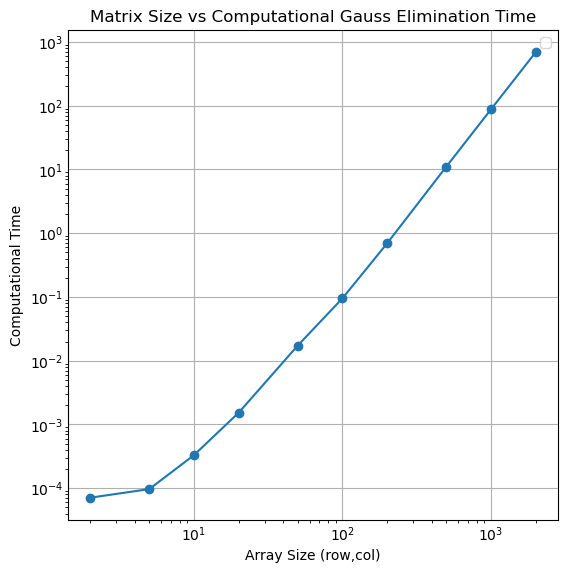

In [922]:
plt.figure(figsize=(5,5))
plt.loglog(N,gauss_elim)
plt.scatter(N,gauss_elim)
plt.xlabel("Array Size (row,col)")
plt.ylabel("Computational Time")
plt.legend()
plt.title("Matrix Size vs Computational Gauss Elimination Time")
plt.show()
#looking at our manual gauss method, the linear portion of our 

(d) Perform a regression on the linear portion of the results (*i.e.*, you may not be able to regress all the data points) to determine the scaling behavior of the computational complexity ($\mathcal{O}(N^2)$, $\mathcal{O}(N^3)$, etc.) of this method.  Do the results you find match the theoretical expectations for Gaussian elimination?  Explain why or why not.

LinregressResult(slope=2.9956644744159737, intercept=-16.227404126293056, rvalue=0.9999942650162194, pvalue=5.734983780647529e-06, stderr=0.007173996065526073, intercept_stderr=0.047068238003646345)


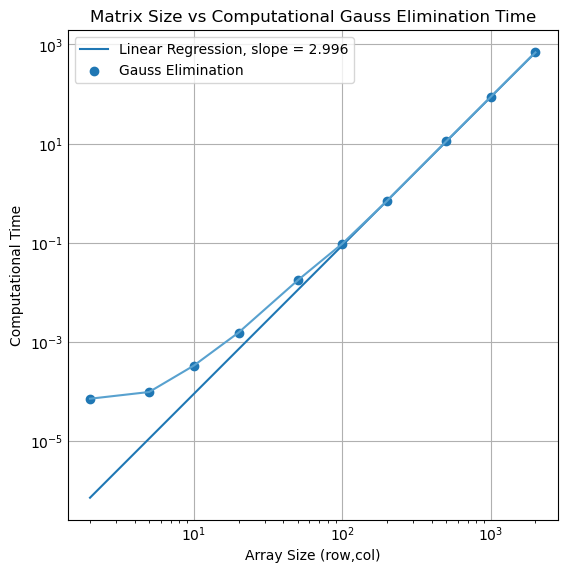

In [965]:
from scipy.stats import linregress
plt.figure(figsize=(5,5))
lin_stats_gauss = linregress(np.log(N[6:]),np.log(gauss_elim[6:]))
print(lin_stats_gauss)
plt.loglog(N, np.exp(lin_stats_gauss)[1]*N**lin_stats_gauss[0],
           label = f"Linear Regression, slope = {lin_stats_gauss[0]:.3f}")
plt.loglog(N,gauss_elim)
plt.scatter(N,gauss_elim,label = "Gauss Elimination")
plt.xlabel("Array Size (row,col)")
plt.ylabel("Computational Time")
plt.legend()
plt.title("Matrix Size vs Computational Gauss Elimination Time")
plt.show()
#looking at our manual gauss method, the linear portion of our results matches expected
#  computational complexity. 
# Looking at our code, there is a for loop with 2 nested forloops (leading to O(N^3))

# for k in range(n-1):    FOR LOOP 1 
#     pivot(A,b,s,n,k)

#     if abs(A[k,k] / s[k]) < tol:
#         er = -1
#         break
#     for i in range(k+1,n):   FOR LOOP 2 
#         factor = A[i,k] / A[k,k]
#         for j in range(k,n):
#             A[i,j]-= factor * A[k,j]

(e) Repeat parts (c) and (d) to determine the time it takes to solve the same matrices using the python library function `numpy.linalg.solve`.  In addition to the matrix sizes N indicated in part (c), please also include N = 5000, 10000, and 20000 in your analysis.  Provide a plot with your measured results and regression that overlays the results for the `numpy` library function and the function that you wrote for Gaussian elimination.  What do you observe? Provide a plausible reason for the difference.

In [900]:
#slope of ~2.34
new_N=[2,5,10,20,50,100,200,500,1000,2000,5000,10000,20000]

import time
def times(N,f,trials=1):
    times=[]
    for length in N:
        A,b = matrix_maker(length)
        t0=time.time()
        for trial in range(trials):
            x=np.linalg.solve(A,b)
        t1=time.time()

        print(f"Nvalue: {length}TIME: {(t1-t0)/trials}")
        times.append((t1-t0)/trials)

    return times



In [901]:
testing123 = times(new_N,3)


Nvalue: 2TIME: 0.0001251697540283203
Nvalue: 5TIME: 2.7179718017578125e-05
Nvalue: 10TIME: 0.0001399517059326172
Nvalue: 20TIME: 0.011428117752075195
Nvalue: 50TIME: 0.02716517448425293
Nvalue: 100TIME: 0.00267791748046875
Nvalue: 200TIME: 0.003545045852661133
Nvalue: 500TIME: 0.007908821105957031
Nvalue: 1000TIME: 0.05107688903808594
Nvalue: 2000TIME: 0.04733896255493164
Nvalue: 5000TIME: 0.5565528869628906
Nvalue: 10000TIME: 2.4640700817108154
Nvalue: 20000TIME: 18.043073177337646


In [942]:
lin_stats_gauss = linregress(np.log(N[6:]),np.log(gauss_elim[6:]))

linalg_numpy = linregress(np.log(new_N[9:]),np.log(testing123[9:]))

print(lin_stats_gauss)
print(linalg_numpy)

LinregressResult(slope=2.9956644744159737, intercept=-16.227404126293056, rvalue=0.9999942650162194, pvalue=5.734983780647529e-06, stderr=0.007173996065526073, intercept_stderr=0.047068238003646345)
LinregressResult(slope=2.5431638621235058, intercept=-22.36059828919733, rvalue=0.9988350958278434, pvalue=0.0011649041721566444, stderr=0.08687586378594209, intercept_stderr=0.7687725316323403)


In [902]:
# plt.figure(figsize=(3,3))
# plt.loglog(new_N,testing123,"o")
# plt.loglog(new_N,testing123)

LinregressResult(slope=2.9956644744159737, intercept=-16.227404126293056, rvalue=0.9999942650162194, pvalue=5.734983780647529e-06, stderr=0.007173996065526073, intercept_stderr=0.047068238003646345)
LinregressResult(slope=2.5093912440320465, intercept=-22.042819729542508, rvalue=0.9965317175348493, pvalue=0.05303687807252233, stderr=0.20954272596993592, intercept_stderr=1.9335999612571277)


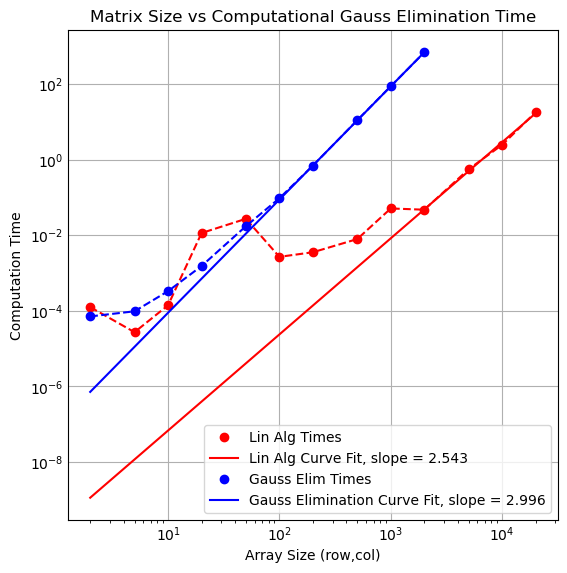

In [966]:
plt.figure(figsize=(5,5))
print(lin_stats_gauss)
linalg_numpy1 = linregress(np.log(new_N[10:]),np.log(testing123[10:]))
print(linalg_numpy1)
plt.loglog(new_N,testing123,"o",color = "red",label = "Lin Alg Times")
plt.loglog(new_N,testing123,color="red",linestyle="--")
plt.loglog(new_N,np.exp(linalg_numpy)[1]*new_N**linalg_numpy[0],color="red",
           label = f"Lin Alg Curve Fit, slope = {linalg_numpy[0]:.3f}")


plt.loglog(N,gauss_elim,color="blue",linestyle="--")
plt.loglog(N,gauss_elim,"o",color="blue",label = "Gauss Elim Times")
plt.loglog(N[:], np.exp(lin_stats_gauss)[1]*N[:]**lin_stats_gauss[0], color = "blue",
           label = f"Gauss Elimination Curve Fit, slope = {lin_stats_gauss[0]:.3f}")
plt.title("Matrix Size vs Computational Gauss Elimination Time")
plt.xlabel("Array Size (row,col)")
plt.ylabel("Computation Time")
plt.legend()
plt.show()

We can see that there are different orders of computation time. We can wee that the sope of lin alg curve fit is smaller, meaning that it is less computationally complex. This makes sensse, as there are many improvements we can make on our function, like vectorizing it. There are also other possible small things to change, like updating certain variables. This makes an insignificant difference, but over 2000 iterations it adds up.

(f) When writing your Gaussian elimination function, you should have used a `for` loop structure to calculate each matrix element in the forward elimination process.  Adapt your function to use vectorization to calculate each matrix element instead, and then repeat parts (c) and (d) to determine the time it takes to solve the same matrices.  Add the results from this method to your plot to highlight the differences. Again, provide a plausible reason for your observations.

In [925]:
def gauss_vec(A,b,tol=1.0e-9):
    n=len(b)
    s=np.zeros(n)
    x=np.zeros(n)
    err = 0 
    for i in range(n):
        s[i]=np.max(np.abs(A[i,:]))

    for k in range(n-1):
        pivot(A,b,s,n,k)
        if np.abs(A[k,k] / s[k]) < tol:
            err = -1
            break
        for i in range(k+1,n):
            factor = A[i,k] / A[k,k]
            A[i,k:n] = A[i,k:n] - factor*A[k,k:n]
            b[i]-= factor * b[k]

    if np.abs(A[n-1,n-1] / s[n-1]) < tol:
        err = -1

    if err != -1:
        x=back_substitution(A,b)

    return x,err

In [927]:
N=[2,5,10,20,50,100,200,500,1000,2000]
print(N)
gauss_vec = times(N,gauss_vec)
print(gauss_vec)

[2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000]
Nvalue: 2TIME: 0.00014090538024902344
Nvalue: 5TIME: 0.00014281272888183594
Nvalue: 10TIME: 0.0006079673767089844
Nvalue: 20TIME: 0.001989126205444336
Nvalue: 50TIME: 0.006575107574462891
Nvalue: 100TIME: 0.016228914260864258
Nvalue: 200TIME: 0.05206608772277832
Nvalue: 500TIME: 0.30775880813598633
Nvalue: 1000TIME: 1.295517921447754
Nvalue: 2000TIME: 5.686625003814697
[0.00014090538024902344, 0.00014281272888183594, 0.0006079673767089844, 0.001989126205444336, 0.006575107574462891, 0.016228914260864258, 0.05206608772277832, 0.30775880813598633, 1.295517921447754, 5.686625003814697]


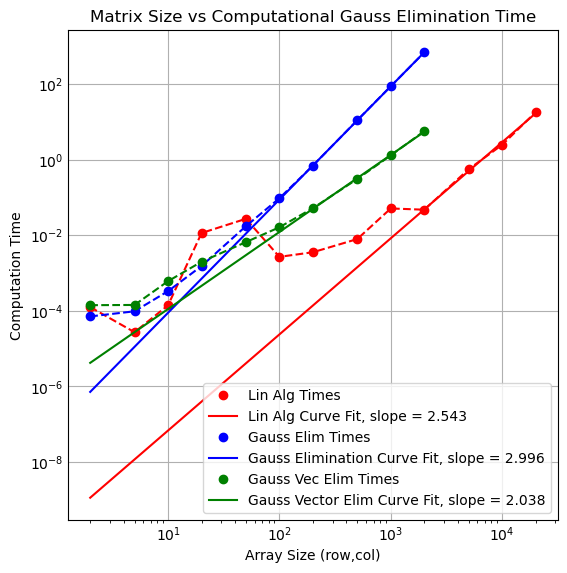

In [967]:
plt.figure(figsize=(5,5))

plt.loglog(new_N,testing123,"o",color = "red",label = "Lin Alg Times")
plt.loglog(new_N,testing123,color="red",linestyle="--")
plt.loglog(new_N,np.exp(linalg_numpy)[1]*new_N**linalg_numpy[0],color="red",
           label = f"Lin Alg Curve Fit, slope = {linalg_numpy[0]:.3f}")


plt.loglog(N,gauss_elim,color="blue",linestyle="--")
plt.loglog(N,gauss_elim,"o",color="blue",label = "Gauss Elim Times")
plt.loglog(N[:], np.exp(lin_stats_gauss)[1]*N[:]**lin_stats_gauss[0], color = "blue",
           label = f"Gauss Elimination Curve Fit, slope = {lin_stats_gauss[0]:.3f}")

plt.loglog(N,gauss_vec,"o",color="green", label = "Gauss Vec Elim Times")
plt.loglog(N,gauss_vec,color="green",linestyle="--")
linalg_vec = linregress(np.log(N[6:]),np.log(gauss_vec[6:]))
plt.loglog(N[:], np.exp(linalg_vec)[1]*N[:]**linalg_vec[0], color = "green",
           label = f"Gauss Vector Elim Curve Fit, slope = {linalg_vec[0]:.3f}")


plt.title("Matrix Size vs Computational Gauss Elimination Time")
plt.xlabel("Array Size (row,col)")
plt.ylabel("Computation Time")
plt.legend()
plt.show()

Here, we can actually see now that that our updated gauss vector elimination is the fastest! This is interesting. I feel like this is because of couple of things. Maybe linalg_solve uses a very similar method of solving the system like we do, except they may have more complex error checking, leading to a higher complexity. They may also be solving for a larger variety of equations, leading to different ways of computing. Also, the computation time varies a lot, and we only did a linear regression of the last 4 points. Taking a linear regression of the entire curve (which is non linear), may actually decrease the computanional complexity to be the lowest.

### Problem 4 - Steady-State Heat Transfer

(a)  Write a function to perform the Gauss-Seidel method called `gauss_seidel()` and test it on the following system of linear equations. 

$$\frac{30}{4}x_{1} - \frac{7}{5}x_{2} + 1x_{3} = \frac{473}{\frac{11}{2}}$$
$$\frac{5}{8}x_{1} + \frac{70}{11}x_{2} - 2x_{3} = -12$$
$$5x_{1} - 4x_{2} + 6x_{3} = 10$$

Plot the iterative guesses on a 3D graph where you treat $x_{1}, x_{2}, x_{3}$ as $x,y,z$, respectively. What are the final values of $x_{1}$, $x_{2}$, and $x_{3}$?  Prove this is the correct solution by substituting these values into the original equations and proving the equalities.  How many iterations does it take to find this solution?

Hint #1: This function should take A, b, and a convergence tolerance (with a default value of 1e-6) as inputs.  Use approximate fractional relative error as your metric for convergence.

Hint #2:  If you encounter errors, then it is recommended that you check if your matrix is diagonally dominant and recast the system as needed.

In [702]:
A=np.array([[30/4,-7/5,1],[5/8,70/11,-2],[5,-4,6]])
b=np.array([473/(11/2),-12,10])


# Write your function here:
def gauss_seidel(a,b,es=1e-6,max_iter=10000,lamda=1):
    
    n=len(b)
    x = np.zeros(n)
    x_guess=[]
    #
    # x_guess = [[0,0,0]]
    for i in range(0,n):
        dummy = a[i,i]
        for j in range(0,n):
            a[i,j] = a[i,j] / dummy
        b[i]=b[i]/dummy#this may cause some issue, because b is 1D, dummy is 2D?

    for i in range(0,n):
        sum = b[i]
        for j in range(0,n):
            if i!=j:
                sum = sum - a[i,j]*x[j]
        x[i]=sum


    iter = 0
    while True:
        sentinel = 1
        for i in range(0,n):
            old = x[i]
            sum=b[i]
            for j in range(0,n):
                if i != j:
                    sum = sum-a[i,j]*x[j]
            x[i]=lamda*sum+(1-lamda)*old
            
            if sentinel == 1 and x[i]!= 0:
                ea = np.abs((x[i]-old)/x[i])#*100
                if ea >es:
                    sentinel = 0 
       #print(iter)

        x_guess.append(list(x))
        #print(x_guess)
        iter+=1
        
        if sentinel == 1 or iter>= max_iter:
            break

    return x,iter,x_guess


In [968]:
#Solving the system:
heat_transfer_coords,iters,x_guesses = gauss_seidel(A,b,lamda = 1)
print(f"Iterations: {iters}")
# print((x_guesses))
#print(heat_transfer_coords)
print(f"Final Solution Coordinates: x1 = {heat_transfer_coords[0]}, \
x2 = {heat_transfer_coords[1]}, x3 = {heat_transfer_coords[2]}")
# print(x_guesses[0])

x_vals=[]
y_vals=[]
z_vals=[]
for i in range(len(x_guesses)):
    x_vals.append(x_guesses[i][0])
    y_vals.append(x_guesses[i][1])
    z_vals.append(x_guesses[i][2])


Iterations: 10
Final Solution Coordinates: x1 = 11.865849950281977, x2 = -7.128643191819429, x3 = -12.973970419781267


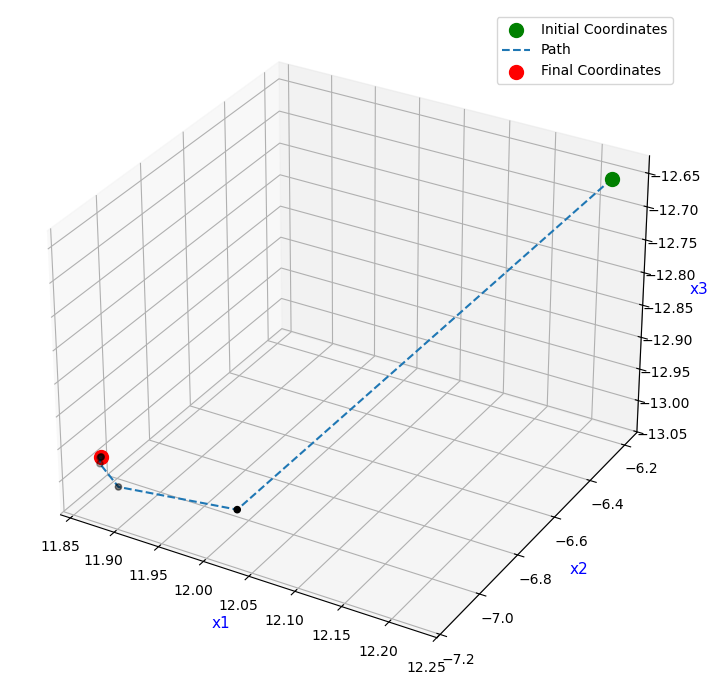

In [969]:
fig = plt.figure(figsize=(7,7))

ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.scatter(x_vals[0],y_vals[0],z_vals[0],color="green",s=100,
           label = "Initial Coordinates")
ax.plot(x_vals[:],y_vals[:],z_vals[:],label = "Path",linestyle="--")
ax.scatter(x_vals[1:-2],y_vals[1:-2],z_vals[1:-2],color="black")
ax.scatter(x_vals[-1],y_vals[-1],z_vals[-1],color="red",s=100,
           label = "Final Coordinates")
ax.set_xlabel("x1",fontsize=11,color="blue")
ax.set_ylabel("x2",fontsize=11,color="blue")
ax.set_zlabel("x3",fontsize=11,color="blue")
#ax.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Iterations: 191


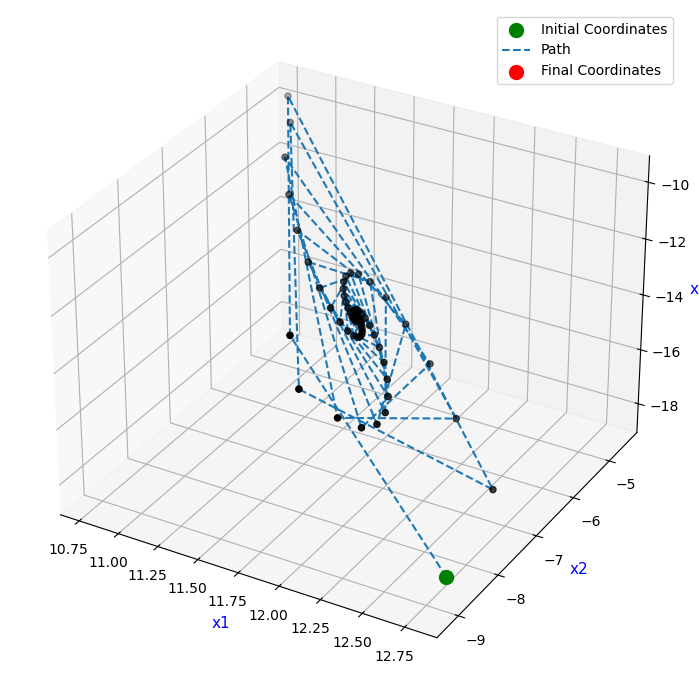

In [970]:
#We can also observe the underdamping by the lambda values that mark talked about today in class and see the oscilatory motion here.
#We also see that this takes a lot more iterations

#Solving the system:
heat_transfer_coords2,iters2,x_guesses2 = gauss_seidel(A,b,lamda = 1.75)

x_vals2=[]
y_vals2=[]
z_vals2=[]
for i in range(len(x_guesses2)):
    x_vals2.append(x_guesses2[i][0])
    y_vals2.append(x_guesses2[i][1])
    z_vals2.append(x_guesses2[i][2])

print(f"Iterations: {iters2}")
fig = plt.figure(figsize=(7,7))

ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.scatter(x_vals2[0],y_vals2[0],z_vals2[0],color="green",s=100,
           label = "Initial Coordinates")
ax.plot(x_vals2[:],y_vals2[:],z_vals2[:],label = "Path",linestyle="--")
ax.scatter(x_vals2[1:-2],y_vals2[1:-2],z_vals2[1:-2],color="black")
ax.scatter(x_vals2[-1],y_vals2[-1],z_vals2[-1],color="red",s=100,
           label = "Final Coordinates")
ax.set_xlabel("x1",fontsize=11,color="blue")
ax.set_ylabel("x2",fontsize=11,color="blue")
ax.set_zlabel("x3",fontsize=11,color="blue")
#ax.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [977]:
def checker(x,y,z):
    if round(30/4*x-7/5*y+z) == (473)/(11/2):
        #we have to use round here, because there's round off error with our 
        # values and it won't equal exactly 86.0
        print(f"Using the solution x1={x}, x2={y}, x3={y}, \
the first equation is satisfied! :)")
        #print(30/4*x-7/5*y+z)
    else:
        print(f"Using the solution x1={x}, x2={y}, x3={y}, \
the first equation is NOT satisfied! :(")
        print(30/4*x-7/5*y+z)
        print(473/(11/2))

    if round(5/8*x+70/11*y-2*z) == (-12):
        print(f"Using the solution x1={x}, x2={y}, x3={y}, \
the second equation is satisfied! :)")

    else:
        print(f"Using the solution x1={x}, x2={y}, x3={y}, \
the second equation is NOT satisfied! :(")


    if round(5*x-4*y+6*z) == 10:
        print(f"Using the solution x1={x}, x2={y}, x3={y},\
 the third equation is satisfied! :)")

    else:
        print(f"Using the solution x1={x}, x2={y}, x3={y}, \
the third equation is NOT satisfied! :(")

checker(x_vals[-1],y_vals[-1],z_vals[-1])

Using the solution x1=11.865849950281977, x2=-7.128643191819429, x3=-7.128643191819429, the first equation is satisfied! :)
Using the solution x1=11.865849950281977, x2=-7.128643191819429, x3=-7.128643191819429, the second equation is satisfied! :)
Using the solution x1=11.865849950281977, x2=-7.128643191819429, x3=-7.128643191819429, the third equation is satisfied! :)


(b)  Steady-state heat flow can be modeled in two-dimensions by the Laplace heat equation as follows: $$\frac{\partial T^{2}}{\partial x^{2}}+\frac{\partial T^{2}}{\partial y^{2}}=0$$

(i) Solve for the steady-state solution to this equation using finite-difference methods given the following boundary conditions of a unit square surface (*i.e.*, $x \in (0,1)$ and $y \in (0, 1)$):

$$\begin{align}
    T(x,0) &= 0 \\
    T(x,1) &= 100 \text{ C} \\
    T(0,y) &= 100 \text{ C} \\
    T(1,y) &= 0
\end{align}$$

Start by linearizing the PDE by using a central finite difference method to approximate the second derivative expanded around $x_{i}$ and $y_{j}$.  Write in a markdown window or upload a photo indicating your derivation of the linear equation that defines the system. 

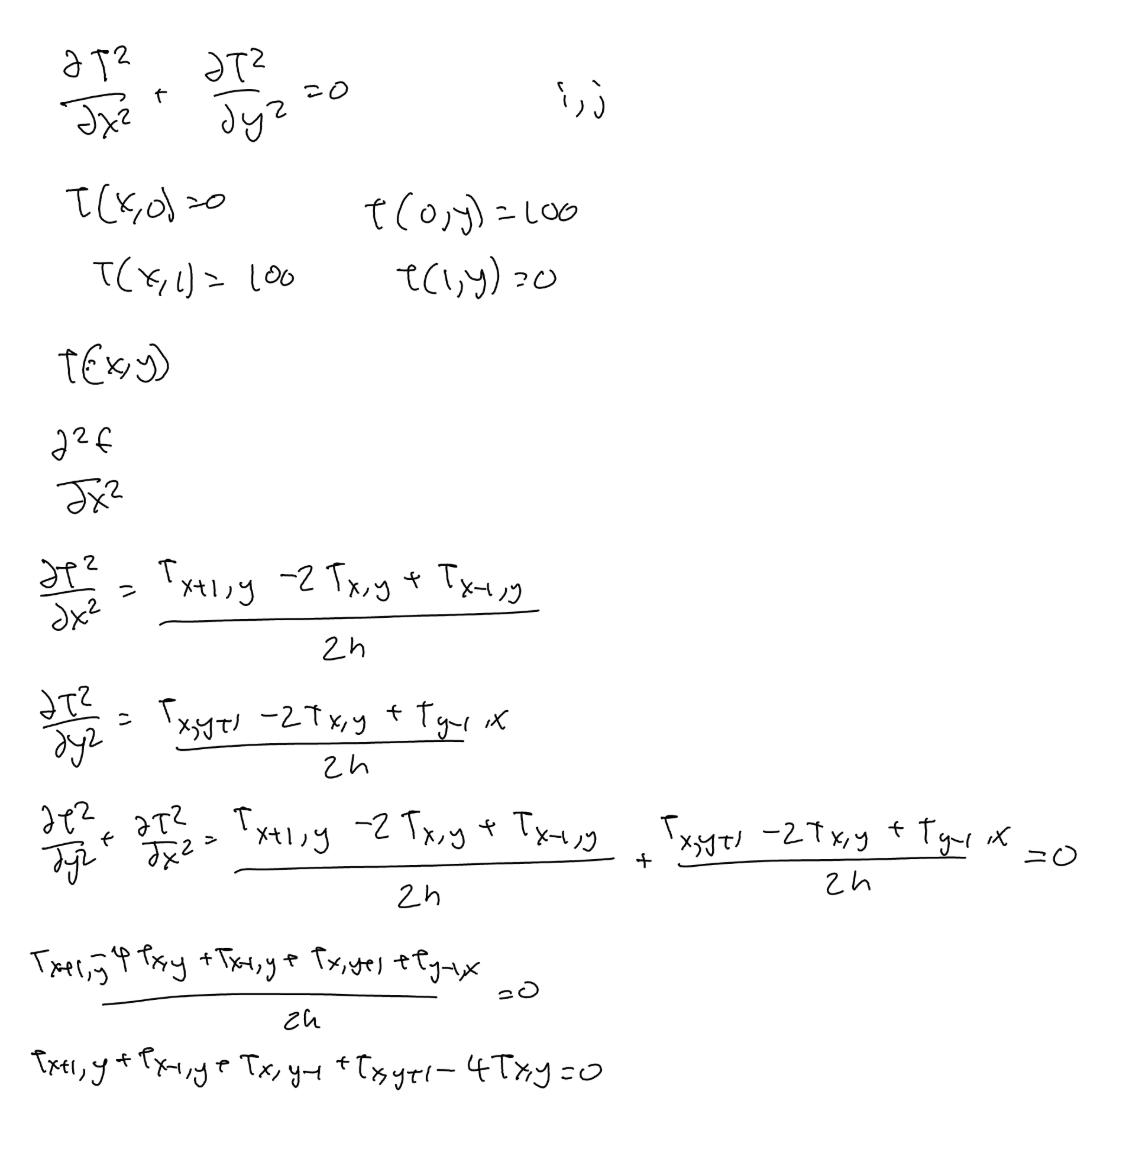

(ii) Define a "temperature grid" with 21 rows and 21 columnn using a step size of $h=\frac{1}{20}$ in both the x and y directions to define the temperature at positions across the surface. The boundary conditions are specified as fixed temperatures, which means you only need to solve for the temperature for the internal points defined by the middle 19 rows and 19 columns (*i.e.*, by excluding the "exterior" rows and columns). Assume $x$ and $y$ have units of meters.

Next, apply the linearized approximations for the Laplace equation at each interior point.  Setup this system of linear equations in a convenient format.  Then compute the solution to this system of equations using your Gauss-Seidel method.  How many iterations did it take to converge on a solution with a maximum approximate fractional relative error for any $T(x_{i},y_{j})$ of less than 1e-6? This may take around a minute for your computer to run! 

In brief, to solve:
1. Use your linear equation to fill in a matrix A and a vector b that define the system for each of the internal points.
2. Directly call the `gauss_seidel()` function that you have written to solve the system of equations.

Hint: Pay attention to the diagonal of your matrix A. In order to ensure convergence of the Gauss-Seidel method, the diagonal term should always have the largest magnitude in its row.

In [855]:
temp_grid = np.zeros([21,21])
x = np.arange(0,1+1/20,1/20)
y = np.arange(0,1+1/20,1/20)
#print(x)

def CFD(step,x_range,y_range,BC1X,BC2X,BC1Y,BC2Y):
    x_start,x_end,y_start,y_end = x_range[0],x_range[-1],y_range[0],y_range[-1]
    length = len(x_range)
    array_length = length-2
    n=len(x_range)
    #print(n)
    number = np.arange(x_start,y_start+step/2,step)
    A=np.zeros((array_length**2,array_length**2))

    c = np.zeros((array_length**2,1))

    for i in range(array_length):
        for j in range(0,array_length):
            index = j+i*array_length
            #r=number[i+1]


            A[index,index]=4

#x value = 0, temp = 100
            if i>0:
                A[index,index-array_length]=-1
            else:
                c[index]+=BC1X

            if i < array_length-1:
                A[index,index+array_length]=-1
            else:
                c[index]+=BC2X

            if j>0:
                A[index,index-1] = -1
            else:
                c[index] += BC1Y

            if j < array_length-1:
                # print(j)
                # print(index)
                # print(index+n)
                A[index,index+1] = -1
            else:
                c[index]+=BC2Y

    return A,c
#print(len(x))
A1,c1 = CFD(1/20,x,y,100,0,0,100)
#print(A)

sol,iter,guesses = gauss_seidel(A1,c1)

#print(sol)

#print(iter)

/var/folders/yl/pdpwhczs2nn2_psnp4h83_lr0000gn/T/ipykernel_1531/1319626099.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x[i]=sum
/var/folders/yl/pdpwhczs2nn2_psnp4h83_lr0000gn/T/ipykernel_1531/1319626099.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x[i]=lamda*sum+(1-lamda)*old


(c)  Plot the solution for temperature $T(x,y)$ on a 2D contour map.  Include a colorbar, and choose a `cmap` that makes sense for a temperature gradient. 

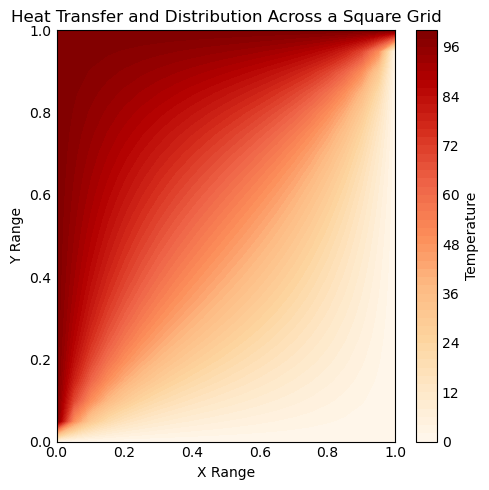

In [866]:

testing=sol.reshape(19,19).T #we also need to transpose
#testing=testing

#now we need to add in the boudanry condtions, and update the size of our array (21,21)

full_temps = np.zeros((21,21))
#at left col, is all o
#at right col, is all 100
#at top row, is all 100
#at bottom row, is all 0 

full_temps[:, 0]  = 100#Left (x=0)
full_temps[:, -1] = 0# right (x=1)
full_temps[0, :]  = 0 # bottom (y=0)
full_temps[-1, :] = 100 #top (y=1)

full_temps[1:-1,1:-1] =testing


plt.figure(figsize=(5,5))
plt.contourf(x,y,full_temps,levels=50,cmap="OrRd")
plt.xlabel("X Range")
plt.ylabel("Y Range")
bar = plt.colorbar()

bar.set_label("Temperature")
plt.title("Heat Transfer and Distribution Across a Square Grid")
plt.tight_layout()
plt.show()
